In [1]:
# Last edited by Nana Kiziriya on May 1, 2026
# Originally developed on Google Colab, uploaded to GitHub

#**Restart entire session before all reruns to avoid unintended consequences...*

This program accepts a spreadsheet of *[time ,variable groups ,control group]* experimental data.

It exports the data cleaned and normalized. Plot images available, too. More details below.

In [2]:
#@title **Imports**
#@markdown
import os.path
from typing import Final
import numpy as np              # basic math
import pandas as pd             # read/write data spreadsheets
from pandas.api.types import is_list_like   # list, tuple, series, NOT string
import matplotlib.pyplot as plt # plotting
import datetime as dt
# from scipy.integrate import solve_ivp     # if model is ODE

In [3]:
#@title #**0. Import Data Set + Preliminary Cleaning ⬇️**

# Terminology:
# replicate groups = variable groups + control group
# trials in (replicate) group
# DataFrame ~table (df), Series ~column (ser), dict ~label->element


#@markdown #### **[ Enter path to data file ]**
dirty_path:Final[str] = '/content/Kurchak_50CF4R9_50R9_ATP_THPP conc var.xlsx' #@param {type:'string'}
#@markdown >##### E.g. */content/myData.xlsx* or */home/Jane/Desktop/myData.csv*
#@markdown >##### Note: Time must be in *1st column*

#@markdown #### <br>**[ What column label indicates the control group? (Partial keyword is okay.) ]**
ctrl_kw = 'blank' #@param {type:'string'}

#@markdown #### <br>**[ How many datapoints to be used for trial pre-scaling? (Keep it low...) ]**
len_prescale = 3 #@param {type:'integer'}
assert(len_prescale>0)

In [4]:
#@title ### Export formatting


#@markdown # <br>**[ Units ]**


#@markdown ##### <br>**[ Enter TIME unit ]**
x_unit = 'Hours' #@param {type:'string'}

#@markdown ##### <br>**[ Enter ORIGINAL unit of measurement ]**
y_unit_dirty = 'Fluorescence' #@param {type:'string'}

#@markdown ##### <br>**[ Enter NORMALIZED unit ]**
y_unit_clean = 'Degree of aggregation' #@param {type:'string'}

#@markdown ##### <br>**[ What's the independent variable in your experiment? (*Not* time.) ]**
indep_var = 'THPP concentration' #@param {type:'string'}


#@markdown # <br>**[ Program Output ]**

#@markdown ##### <br>**[ Export cleaned normalized data? ]**
exportData = True #@param {type:'boolean'}

#@markdown ##### <br>**[ Export plot images? ]**
exportImages = True #@param {type:'boolean'}

#@markdown ##### <br>**[ ... Transparent images? ]**
tpImg = False #@param {type:'boolean'}

#@markdown ##### <br>**[ Select image file extension ]**
img_ext = '.svg' #@param ['.png','.jpeg','.svg','pdf'] {type:'string'}
#@markdown >##### Note: *.jpeg* does not support transparency , *.svg* is vector-based (scalable)


#@markdown ##### <br>**[ Print messages? (For debugging.) ]**
doPrint = False #@param {type:'boolean'}

In [5]:
#@title **Useful Methods**
#@markdown

cond_print = lambda *s : print(*s) if doPrint else None

def groupAvgSeries(df:pd.DataFrame,name=None) :
  return pd.Series([
    np.average([
        entry
        for entry in
        df.iloc[row,:] ])
    for row in
    range(df.shape[0])
    ],name=name)



# PLOTTING

rainbow = ['r','orange','g','b','purple'] # colors for variable groups
ctrl_color = 'gray' # color for control group

def plotDataFrame(x_axis,df:pd.DataFrame,title:str=None,x_label:str=None,y_label:str=None,labels=None,replicates:bool=False,colors=None) :

  labels = df.columns if labels==None else labels if is_list_like(labels) else [labels]
  colors = colors if is_list_like(colors) else [colors]

  for j in range(df.shape[1]):
    plt.plot(
        x_axis,
        df.iloc[:,j],
        color = colors[j%len(colors)],
        label = (labels[0] if j==0 else None) if replicates else labels[j%len(labels)]
        )
  plt.xlabel(x_label)
  plt.ylabel(y_label)
  plt.title(title)



# FILE EXPORT

def _timestampPath(path) :
  dot = path.rfind('.')
  rtfn = dt.datetime.now()
  rtfn = f'_{rtfn.year}_{rtfn.month}_{rtfn.day}_{rtfn.hour}{rtfn.minute}{rtfn.second}'
  return path[:dot] + rtfn + path[dot:] if dot>-1 else path+rtfn

def _fixId(id:str) :
  return ('_' + id.strip(' _.')).replace(' ','_').replace('.','_')

def exportDataFrame(df:pd.DataFrame,id:str='ALTERED') :

  dot = dirty_path.rfind('.')
  clean_path = dirty_path[:dot] + _fixId(id) + dirty_path[dot:]

  cleaner_path = _timestampPath(clean_path)
  while os.path.isfile(cleaner_path) :
    cleaner_path = _timestampPath(clean_path)

  try:
    df.to_excel(cleaner_path,index=False)
  except:
    print('Something went wrong while exporting',id,'data.')

def exportPlot(id='PLOTLY') :

  dot = dirty_path.rfind('.')
  clean_path = dirty_path[:dot] + _fixId(id) + img_ext

  cleaner_path = _timestampPath(clean_path)
  while os.path.isfile(cleaner_path) :
    cleaner_path = _timestampPath(clean_path)

  try:
    plt.savefig(cleaner_path, transparent=tpImg)
  except:
    print(f'Something went wrong while exporting',id,'plot image.')




In [6]:
#@title ### Convert to dataframe

# Convert file to pandas dataframe
df_dirty = pd.read_excel(dirty_path)

assert(df_dirty.shape[1]>2) # need 1 time column, at least 1 control, and at least 1 trial

cond_print('Before dropping NaN rows:\n', df_dirty)

In [7]:
#@title ### Drop NaN row

df_dirty.drop(df_dirty.shape[0]-1, inplace=True)

cond_print('After dropping NaN rows:\n', df_dirty)

In [8]:
#@title ### Separate the time column

# BEFORE: df_dirty
# AFTER:  ser_time | df_trials(no times)

ser_time = df_dirty.pop(df_dirty.columns[0])
cond_print(ser_time)
assert(ser_time.name not in df_dirty.columns)
df_trials = df_dirty; del df_dirty # renaming

In [9]:
#@title ### Fix column naming for replicate trials, and separate the replicate groups
# PURPOSE: If spreadsheet has merged column headings to represent replicate groups, pd.DataFrame uses label for 1st column in group, and names other group members 'Unnamed:NUM'

# BEFORE: ser_time | df_trials
# AFTER:  ser_time | dict_groups_df(df_trials sep. by group)

target = 'Unnamed'

dict_groups_df = dict() # {group_N_label : df_group_N}

if target in str(df_trials.columns) and not all(target in col for col in df_trials.columns):
  cond_print(f'Before rename:\n{df_trials.columns}\n')

  trial_relabels = dict() # {old_label : new_label}
  group_splits = [] # [num_trials_grp1, num_trials_grp2, ...]
  group_labels = [] # ['grp1', 'grp2', ...]
  group_label = target
  trial_count = 0

  for trial_label in df_trials.columns :

    if target not in trial_label : # if column is named (i.e. new group)...

      if trial_count>0 : # store previous group info if nonempty...
        group_splits.append(trial_count)
        group_labels.append(group_label)

      group_label = trial_label # update group label (dict_key)
      trial_count = 0 # reset trial count

    trial_count+=1
    trial_relabels.update({trial_label:f'{group_label} [v.{trial_count}]'})

  # Store last group
  group_splits.append(trial_count)
  group_labels.append(group_label)

  df_trials.rename(columns=trial_relabels, inplace=True) # relabel columns

  print(group_splits)
  print(group_labels)
  # print(trial_relabels)
  print(df_trials.columns)

  del group_label, trial_count, trial_relabels

  assert(sum(group_splits)==len(df_trials.columns)) # num_columns preserved
  assert(len(group_splits)==len(group_labels)) # num_groups preserved

  cond_print(f'After rename:\n{df_trials.columns}\n')

  # Splitting:
  for i in range(len(group_splits)) : # for group i ...
    dict_groups_df.update({
        group_labels[i] : # match label i ...
        pd.concat([       # to group of trials (popped off df_trials)
            df_trials.pop(
                df_trials.columns[0]) # trials in ...
            for j in
            range(group_splits[i])    # the first j columns
            ], axis=1)
        })

    assert(g in l for g in group_labels for l in dict_groups_df[g])

else :
  cond_print(f'Nothing to relabel: {df_trials.columns}')
  for col in df_trials.columns :
    dict_groups_df.update({col : df_trials.pop(col) })

assert(df_trials.shape[1]==0)
del df_trials

cond_print(f'After split:')
for group in dict_groups_df.values() :
  cond_print(group,'\n')
del group

[3, 3, 3, 3, 3, 3]
['5\xa0mM', '3\xa0mM', '2\xa0mM', '1\xa0mM', '0.5\xa0mM', 'Nile Red blank']
Index(['5 mM [v.1]', '5 mM [v.2]', '5 mM [v.3]', '3 mM [v.1]', '3 mM [v.2]',
       '3 mM [v.3]', '2 mM [v.1]', '2 mM [v.2]', '2 mM [v.3]', '1 mM [v.1]',
       '1 mM [v.2]', '1 mM [v.3]', '0.5 mM [v.1]', '0.5 mM [v.2]',
       '0.5 mM [v.3]', 'Nile Red blank [v.1]', 'Nile Red blank [v.2]',
       'Nile Red blank [v.3]'],
      dtype='object')


In [10]:
#@title ### Separate the control group

# BEFORE: ser_time | dict_groups_df
# AFTER:  ser_time | dict_vgroups_df(variable groups only, no ctrls) | df_ctrls

ctrl_kw = tuple(filter((lambda _:ctrl_kw.upper() in _.upper()), dict_groups_df)) # use keyword to grab entire control group label
assert len(ctrl_kw)==1 # only 1 group should be the control group
ctrl_kw = ctrl_kw[0]

df_ctrls = dict_groups_df.pop(ctrl_kw)

cond_print(f'CONTROLS:\n{df_ctrls}')

dict_vgroups_df = dict_groups_df; del dict_groups_df

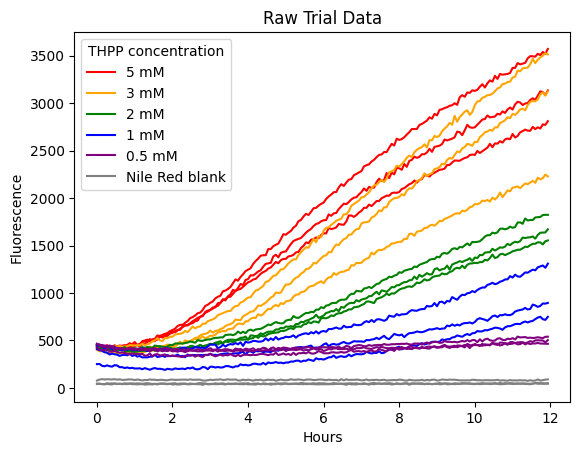

In [11]:
#@title ### **INITIAL VISUALIZATION:**

for k, group in enumerate(dict_vgroups_df):
  plotDataFrame(
      ser_time,
      dict_vgroups_df[group],
      labels=group,
      colors=rainbow[k],
      replicates=True)

plotDataFrame(
    ser_time,
    df_ctrls,
    title='Raw Trial Data',
    x_label=x_unit,
    y_label=y_unit_dirty,
    labels=ctrl_kw,
    colors=ctrl_color,
    replicates=True)

plt.legend(title=indep_var)
exportPlot('DIRTYPLOT')
plt.show()

In [12]:
#@title #**1. Averaging Control Trials**

cond_print(f'Before averaging:\n',df_ctrls)

ser_ctrl = groupAvgSeries(df_ctrls,name=ctrl_kw)
assert(len(ser_ctrl)==df_ctrls.shape[0])
cond_print(f'After averaging:\n',ser_ctrl)
del df_ctrls
# Now we have: ser_time | dict_vgroups_df | ser_ctrl

In [13]:
#@title #**2. Subtract Control Baseline From All Other Trials**

cond_print(f'Before baselining:\n{dict_vgroups_df}\n')

for group in dict_vgroups_df :
  dict_vgroups_df[group] = dict_vgroups_df[group].sub(ser_ctrl, axis=0)

cond_print(f'After baselining:\n{dict_vgroups_df}\n')

In [14]:
#@title #**3. Prescale trials within each group**
# Within in each replicate group, make sure the average of the first few data points match up for each trial
# scale UP to avoid precision loss from truncation

# make sure scaling up does not create overflow error
# to be safe, largest value to power of len_prescale should not overflow
import sys
assert(pd.concat(dict_vgroups_df.values()).max().max() < np.power(sys.float_info.max, (1/len_prescale)))
# IF IT CREATES OVERFLOW, THE FOLLOWING ALGORITHM HAS TO BE REPROGRAMMED. I AM NOT DOING ALL THAT RIGHT NOW.

for group in dict_vgroups_df :
  df = dict_vgroups_df[group]
  prescale_avgs = list(map(
      lambda i :
          np.average([
          pre
          for pre in
          df.iloc[0:len_prescale,i] ]),
      range(df.shape[1])
      ))
  total_prod = np.prod(prescale_avgs)
  prescale_factors = list(map(lambda _:total_prod/_,prescale_avgs))

  # multiply each column j by prescale_factors[j] all at once using df.mul
  assert(len(prescale_factors)==df.shape[1])
  dict_vgroups_df[group] = df.mul(prescale_factors, axis=1)

# for row in
# range(df_ctrls.shape[0])

cond_print(f'After prescaling:\n',dict_vgroups_df)
# starting values in each column should be approximately the same
# if they're very different, consider lowering len_prescale OR using a different algorithm to prescale (would have to be hardcoded :P)
# Note: prescaling is to balance statistical weight of each trial before averaging them


In [15]:
#@title #**4. Average trials in each group, then scale-equalize groups**
# After averaging each group into a series, scale each group to start at 1
# Then put all group columns into a single dataframe

df_vgroups = pd.concat((groupAvgSeries(dict_vgroups_df[group],name=group) for group in dict_vgroups_df), axis=1)

df_vgroups = df_vgroups.div(df_vgroups.iloc[0,:],axis=1)

cond_print(df_vgroups)

In [16]:
#@title #**5. Normalize entire set of values: Scale onto [0,1]**
# max value in df_vgroups should =1

df_vgroups = df_vgroups.div( df_vgroups.max().max() )

assert(1==df_vgroups.max().max())

df_vgroups

,5 mM,3 mM,2 mM,1 mM,0.5 mM
0,0.124385,0.124385,0.124385,0.124385,0.124385
1,0.118969,0.116293,0.119778,0.123779,0.118649
2,0.119493,0.117586,0.116767,0.117240,0.115705
3,0.118962,0.116149,0.116187,0.112443,0.116888
4,0.116298,0.112631,0.112560,0.114844,0.113933
...,...,...,...,...,...
175,0.981252,0.937701,0.512368,0.366184,0.138793
176,0.985265,0.946060,0.516513,0.372297,0.139038
177,0.992053,0.951932,0.516413,0.370529,0.138213
178,0.985390,0.953917,0.519928,0.365695,0.137042


#**In Conclusion...**

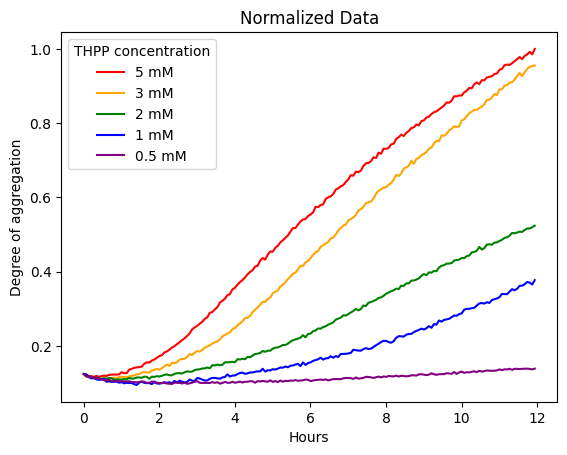

In [17]:
#@title ### **FINAL VISUALIZATION:**

plotDataFrame(
    ser_time,
    df_vgroups,
    title='Normalized Data',
    x_label=x_unit,
    y_label=y_unit_clean,
    colors=rainbow)

plt.legend(title=indep_var)

exportPlot(id='CLEANPLOT')
plt.show()

In [18]:
#@title ###Reinsert time column and export file

# Reinsert time column
df_vgroups.insert(0,ser_time.name,ser_time)

# Exporting
exportDataFrame(df_vgroups, id=f'CLEANDATA_n01ps{len_prescale}')

#***FILE(S) EXPORTED AND READY TO FIT TO YOUR FAVORITE DATA MODEL! :D***